In [29]:
!pip install gensim scikit-learn nltk

In [30]:
import nltk
nltk.download('punkt')
nltk.download('stopwords')

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from gensim.models import Word2Vec
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
import numpy as np

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [31]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

In [32]:
#from google.colab import drive
#drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [54]:
# Step 1: Load the CSV file into a DataFrame
#df = pd.read_csv('/content/drive/My Drive/overview-of-recordings.csv')
df = pd.read_csv('https://www.dropbox.com/scl/fi/qvzhk2zp8f2wpnz7hrqyd/overview-of-recordings.csv?rlkey=vugax3x2k76botbpberqbqzve&st=9omelcyw&dl=1')

df.head(10)

,audio_clipping,audio_clipping:confidence,background_noise_audible,background_noise_audible:confidence,overall_quality_of_the_audio,quiet_speaker,quiet_speaker:confidence,speaker_id,file_download,file_name,phrase,prompt,writer_id
0,no_clipping,1.0000,light_noise,1.0000,3.33,audible_speaker,1.0,43453425,https://ml.sandbox.cf3.us/cgi-bin/index.cgi?do...,1249120_43453425_58166571.wav,When I remember her I feel down,Emotional pain,21665495
1,light_clipping,0.6803,no_noise,0.6803,3.33,audible_speaker,1.0,43719934,https://ml.sandbox.cf3.us/cgi-bin/index.cgi?do...,1249120_43719934_43347848.wav,When I carry heavy things I feel like breaking...,Hair falling out,44088126
2,no_clipping,1.0000,no_noise,0.6655,3.33,audible_speaker,1.0,43719934,https://ml.sandbox.cf3.us/cgi-bin/index.cgi?do...,1249120_43719934_53187202.wav,there is too much pain when i move my arm,Heart hurts,44292353
3,no_clipping,1.0000,light_noise,1.0000,3.33,audible_speaker,1.0,31349958,https://ml.sandbox.cf3.us/cgi-bin/index.cgi?do...,1249120_31349958_55816195.wav,My son had his lip pierced and it is swollen a...,Infected wound,43755034
4,no_clipping,1.0000,no_noise,1.0000,4.67,audible_speaker,1.0,43719934,https://ml.sandbox.cf3.us/cgi-bin/index.cgi?do...,1249120_43719934_82524191.wav,My muscles in my lower back are aching,Infected wound,21665495
5,no_clipping,1.0000,no_noise,1.0000,3.00,audible_speaker,1.0,40663048,https://ml.sandbox.cf3.us/cgi-bin/index.cgi?do...,1249120_40663048_51348478.wav,i have muscle pain that my back\nI Have Muscle...,Foot ache,44130352
6,no_clipping,1.0000,no_noise,1.0000,3.67,audible_speaker,1.0,40663048,https://ml.sandbox.cf3.us/cgi-bin/index.cgi?do...,1249120_40663048_42741720.wav,I have muscle pain in my left leg,Shoulder pain,43913997
7,no_clipping,1.0000,no_noise,1.0000,4.25,audible_speaker,1.0,15004831,https://ml.sandbox.cf3.us/cgi-bin/index.cgi?do...,1249120_15004831_21919890.wav,I have cut my finger because of playing footba...,Injury from sports,43318517
8,no_clipping,0.6978,no_noise,1.0000,3.67,audible_speaker,1.0,14353703,https://ml.sandbox.cf3.us/cgi-bin/index.cgi?do...,1249120_14353703_93481996.wav,I have acne in my face and other problems in m...,Skin issue,44066678
9,no_clipping,1.0000,no_noise,0.6879,3.33,audible_speaker,1.0,43719934,https://ml.sandbox.cf3.us/cgi-bin/index.cgi?do...,1249120_43719934_85316490.wav,I have a strange rash on my arm,Foot ache,44130352


In [34]:
# Drop all columns except 'phrase' and 'prompt'
df = df[['phrase', 'prompt']]

# Display the DataFrame
print(df.head(10))

                                              phrase              prompt
0                    When I remember her I feel down      Emotional pain
1  When I carry heavy things I feel like breaking...    Hair falling out
2          there is too much pain when i move my arm         Heart hurts
3  My son had his lip pierced and it is swollen a...      Infected wound
4             My muscles in my lower back are aching      Infected wound
5  i have muscle pain that my back\nI Have Muscle...           Foot ache
6                  I have muscle pain in my left leg       Shoulder pain
7  I have cut my finger because of playing footba...  Injury from sports
8  I have acne in my face and other problems in m...          Skin issue
9                    I have a strange rash on my arm           Foot ache


In [35]:
# Check if there are any empty values in the 'phrase' column
empty_phrase = df['phrase'].isna().any()

# Check if there are any empty values in the 'prompt' column
empty_prompt = df['prompt'].isna().any()

# Print the results
if empty_phrase:
    print("There are empty values in the 'phrase' column.")
else:
    print("There are no empty values in the 'phrase' column.")

if empty_prompt:
    print("There are empty values in the 'prompt' column.")
else:
    print("There are no empty values in the 'prompt' column.")

There are no empty values in the 'phrase' column.
There are no empty values in the 'prompt' column.


In [36]:
num_rows = len(df)
print("Number of rows:", num_rows)

Number of rows: 6661


In [37]:
# Get the number of unique phrases (X)
num_unique_phrases = df['phrase'].nunique()

# Print the number of unique phrases
print("\nNumber of unique phrases (X):", num_unique_phrases)


Number of unique phrases (X): 706


In [38]:
# Remove rows with duplicate combinations of 'phrase' and 'prompt'
df = df.drop_duplicates(subset=['phrase', 'prompt'])

num_rows = len(df)
print("Number of rows:", num_rows)

Number of rows: 707


In [39]:
# Group the DataFrame by 'phrase' and count the number of unique prompts in each group
phrase_groups = df.groupby('phrase')['prompt'].nunique()

# Filter the groups where more than one unique prompt exists
duplicate_phrases = phrase_groups[phrase_groups > 1]

# Iterate through the duplicate phrases and print the corresponding rows
for phrase in duplicate_phrases.index:
    print(f"Phrase: {phrase}")
    print(df[df['phrase'] == phrase])
    print()

Phrase: I lose a lot of my hair
                      phrase            prompt
20   I lose a lot of my hair   Body feels weak
280  I lose a lot of my hair  Hair falling out



In [40]:
# Drop the row at index 20, the prompt does not match the phrase
df = df.drop(20)

In [41]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

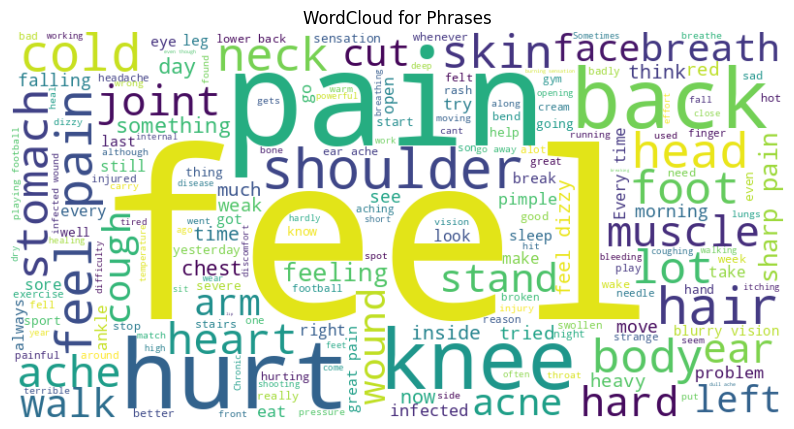

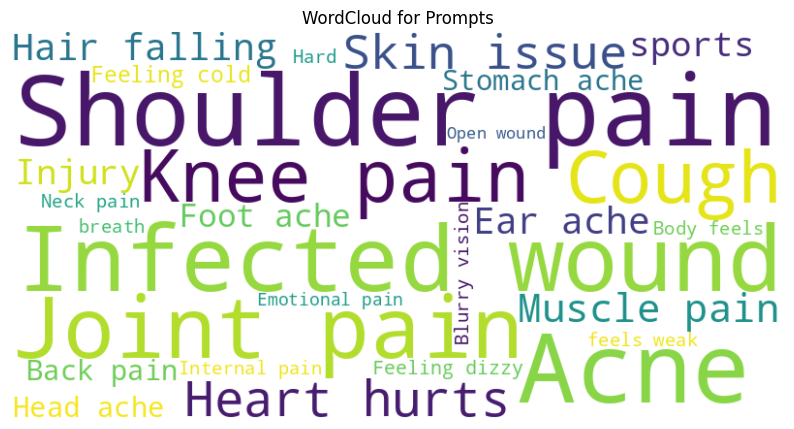

In [42]:
# Concatenate all text from 'prompts' column into a single string
all_prompts = ' '.join(df['prompt'])

# Concatenate all text from 'phrases' column into a single string
all_phrases = ' '.join(df['phrase'])

# Create a WordCloud object for prompts
wordcloud_prompts = WordCloud(width=800, height=400, background_color='white').generate(all_prompts)

# Create a WordCloud object for phrases
wordcloud_phrases = WordCloud(width=800, height=400, background_color='white').generate(all_phrases)

# Plot WordCloud for phrases
plt.figure(figsize=(10, 6))
plt.imshow(wordcloud_phrases, interpolation='bilinear')
plt.title('WordCloud for Phrases')
plt.axis('off')
plt.show()

# Plot WordCloud for prompts
plt.figure(figsize=(10, 6))
plt.imshow(wordcloud_prompts, interpolation='bilinear')
plt.title('WordCloud for Prompts')
plt.axis('off')
plt.show()

In [43]:
import gensim.downloader as api
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import numpy as np
import pandas as pd
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
import string

# Download Word2Vec model (you can also use your own trained model)
word2vec_model = api.load('word2vec-google-news-300')

In [44]:
nltk.download('punkt')
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [45]:
import numpy as np
import pandas as pd
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder
import gensim.downloader as api

In [46]:
# Download Word2Vec model (you can also use your own trained model)
word2vec_model = api.load('word2vec-google-news-300')

In [47]:
from sklearn.svm import SVC
def preprocess_text(text):
    tokens = word_tokenize(text.lower())  # Lowercase all tokens
    tokens = [word for word in tokens if word.isalpha() and word not in stop_words]  # Remove non-alphabetic tokens and stop words
    return tokens

# Generate word embeddings for phrases and prompts
phrase_embeddings = []
prompt_labels = []

for phrase, prompt in zip(df['phrase'], df['prompt']):
    phrase_tokens = preprocess_text(phrase)
    prompt_tokens = preprocess_text(prompt)

    # Calculate embeddings for phrase
    phrase_vec = np.mean([word2vec_model[word] for word in phrase_tokens if word in word2vec_model], axis=0, keepdims=True)
    phrase_embeddings.append(phrase_vec)

    # Use LabelEncoder to encode prompt labels
    prompt_label = prompt  # Assuming prompt is already a label
    prompt_labels.append(prompt_label)

# Convert lists to numpy arrays
X = np.concatenate(phrase_embeddings, axis=0)
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(prompt_labels)  # Encode prompt labels

# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a classification model using Support Vector Machine (SVM)
classifier = SVC()
classifier.fit(X_train, y_train)

# Predict
y_pred = classifier.predict(X_test)

# Evaluate
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.6971830985915493


In [48]:
def preprocess_text(text):
    tokens = word_tokenize(text.lower())  # Lowercase all tokens
    tokens = [word for word in tokens if word.isalpha() and word not in stop_words]  # Remove non-alphabetic tokens and stop words
    return tokens

# Generate word embeddings for phrases and prompts
phrase_embeddings = []
prompt_labels = []

for phrase, prompt in zip(df['phrase'], df['prompt']):
    phrase_tokens = preprocess_text(phrase)
    prompt_tokens = preprocess_text(prompt)

    # Calculate embeddings for phrase
    phrase_vec = np.mean([word2vec_model[word] for word in phrase_tokens if word in word2vec_model], axis=0, keepdims=True)
    phrase_embeddings.append(phrase_vec)

    # Use LabelEncoder to encode prompt labels
    prompt_label = prompt  # Assuming prompt is already a label
    prompt_labels.append(prompt_label)

# Convert lists to numpy arrays
X = np.concatenate(phrase_embeddings, axis=0)
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(prompt_labels)  # Encode prompt labels

# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a classification model (e.g., Logistic Regression)
classifier = LogisticRegression()
classifier.fit(X_train, y_train)

# Predict
y_pred = classifier.predict(X_test)

# Evaluate
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)


Accuracy: 0.7676056338028169


In [49]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score

def preprocess_text(text):
    tokens = word_tokenize(text.lower())  # Lowercase all tokens
    tokens = [word for word in tokens if word.isalpha() and word not in stop_words]  # Remove non-alphabetic tokens and stop words
    return tokens

# Generate word embeddings for phrases and prompts
phrase_embeddings = []
prompt_labels = []

for phrase, prompt in zip(df['phrase'], df['prompt']):
    phrase_tokens = preprocess_text(phrase)
    prompt_tokens = preprocess_text(prompt)

    # Calculate embeddings for phrase
    phrase_vec = np.mean([word2vec_model[word] for word in phrase_tokens if word in word2vec_model], axis=0, keepdims=True)
    phrase_embeddings.append(phrase_vec)

    # Use LabelEncoder to encode prompt labels
    prompt_label = prompt  # Assuming prompt is already a label
    prompt_labels.append(prompt_label)

# Convert lists to numpy arrays
X = np.concatenate(phrase_embeddings, axis=0)
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(prompt_labels)  # Encode prompt labels

# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a classification model using Gradient Boosting Classifier
classifier = GradientBoostingClassifier()
classifier.fit(X_train, y_train)

# Predict
y_pred = classifier.predict(X_test)

# Evaluate
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)


Accuracy: 0.49295774647887325


In [53]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

def preprocess_text(text):
    tokens = word_tokenize(text.lower())  # Lowercase all tokens
    tokens = [word for word in tokens if word.isalpha() and word not in stop_words]  # Remove non-alphabetic tokens and stop words
    return tokens

# Generate word embeddings for phrases and prompts
phrase_embeddings = []
prompt_labels = []

for phrase, prompt in zip(df['phrase'], df['prompt']):
    phrase_tokens = preprocess_text(phrase)
    prompt_tokens = preprocess_text(prompt)

    # Calculate embeddings for phrase
    phrase_vec = np.mean([word2vec_model[word] for word in phrase_tokens if word in word2vec_model], axis=0, keepdims=True)
    phrase_embeddings.append(phrase_vec)

    # Use LabelEncoder to encode prompt labels
    prompt_label = prompt  # Assuming prompt is already a label
    prompt_labels.append(prompt_label)

# Convert lists to numpy arrays
X = np.concatenate(phrase_embeddings, axis=0)
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(prompt_labels)  # Encode prompt labels

# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a classification model using Random Forest Classifier
rf_classifier = RandomForestClassifier()
rf_classifier.fit(X_train, y_train)

# Predict using Random Forest Classifier
y_pred_rf = rf_classifier.predict(X_test)

# Evaluate Random Forest Classifier
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print("Random Forest Classifier Accuracy:", accuracy_rf)


Random Forest Classifier Accuracy: 0.676056338028169


In [50]:
def preprocess_text(text):
    tokens = word_tokenize(text.lower())  # Lowercase all tokens
    tokens = [word for word in tokens if word.isalpha() and word not in stop_words]  # Remove non-alphabetic tokens and stop words
    return tokens

# Suppose you have a new phrase
new_phrase = "Can't sleep, feeling restless and sore"

# Preprocess the new phrase
new_phrase_tokens = preprocess_text(new_phrase)

# Calculate the embedding for the new phrase
new_phrase_embedding = np.mean([word2vec_model[word] for word in new_phrase_tokens if word in word2vec_model], axis=0, keepdims=True)

# Predict the prompt label for the new phrase
predicted_prompt_label = classifier.predict(new_phrase_embedding)

# Decode the predicted prompt label
predicted_prompt = label_encoder.inverse_transform(predicted_prompt_label)

print("Predicted Prompt:", predicted_prompt)


Predicted Prompt: ['Body feels weak']


In [51]:
def preprocess_text(text):
    tokens = word_tokenize(text.lower())  # Lowercase all tokens
    tokens = [word for word in tokens if word.isalpha() and word not in stop_words]  # Remove non-alphabetic tokens and stop words
    return tokens

# Suppose you have a new phrase
new_phrase = "My knees hurt when I walk"

# Preprocess the new phrase
new_phrase_tokens = preprocess_text(new_phrase)

# Calculate the embedding for the new phrase
new_phrase_embedding = np.mean([word2vec_model[word] for word in new_phrase_tokens if word in word2vec_model], axis=0, keepdims=True)

# Predict the prompt label for the new phrase
predicted_prompt_label = classifier.predict(new_phrase_embedding)

# Decode the predicted prompt label
predicted_prompt = label_encoder.inverse_transform(predicted_prompt_label)

print("Predicted Prompt:", predicted_prompt)

Predicted Prompt: ['Knee pain']
